## Чтение и предобработка данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("data/student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [4]:
df.drop(columns=["Student_ID"], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [14]:
df = df.rename(
    columns={
        "CGPA": "Efficiency",
        "Sleep_Duration": "Sleep",
        "Study_Hours": "Study",
        "Social_Media_Hours": "Social Media",
        "Physical_Activity": "Sport",
        "Stress_Level": "Stress",
    }
)
df.head()

,Age,Gender,Department,Efficiency,Sleep,Study,Social Media,Sport,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Обработка дубликатов строк

In [15]:
print("До", df.shape)

df = df.drop_duplicates()

print("После", df.shape)

До (100000, 10)
После (100000, 10)


## Распределения

Найдено числовых признаков: 7



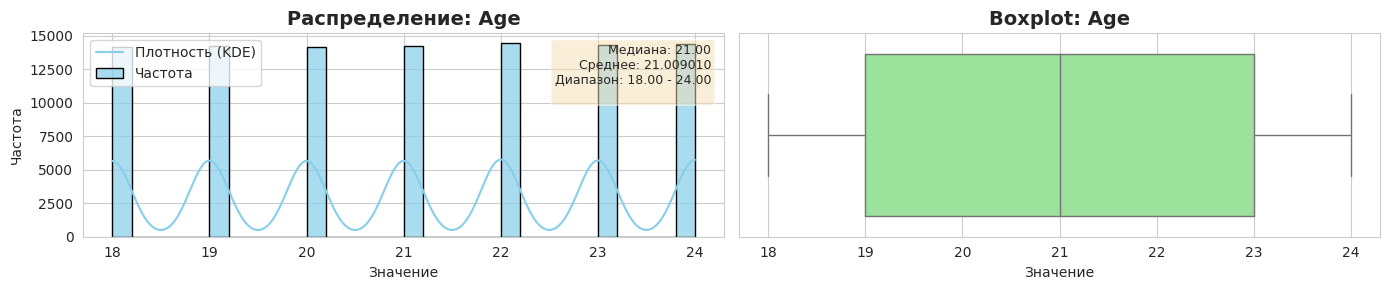

Выбросов (IQR) в Age: 0


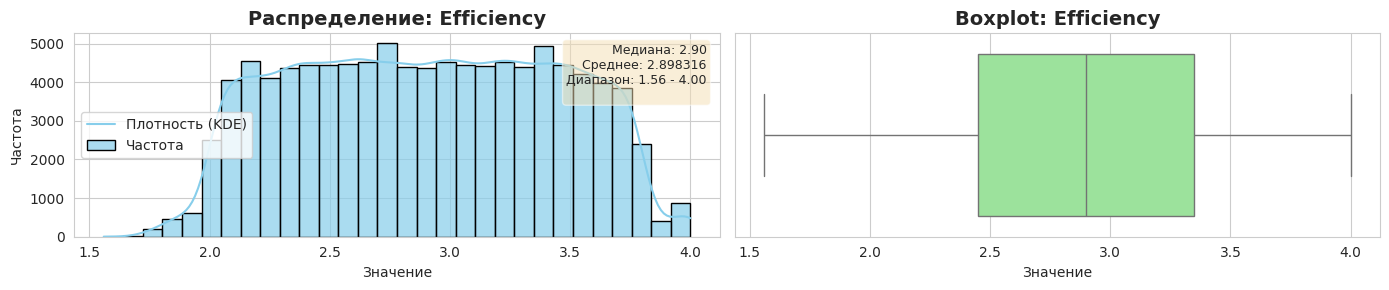

Выбросов (IQR) в Efficiency: 0


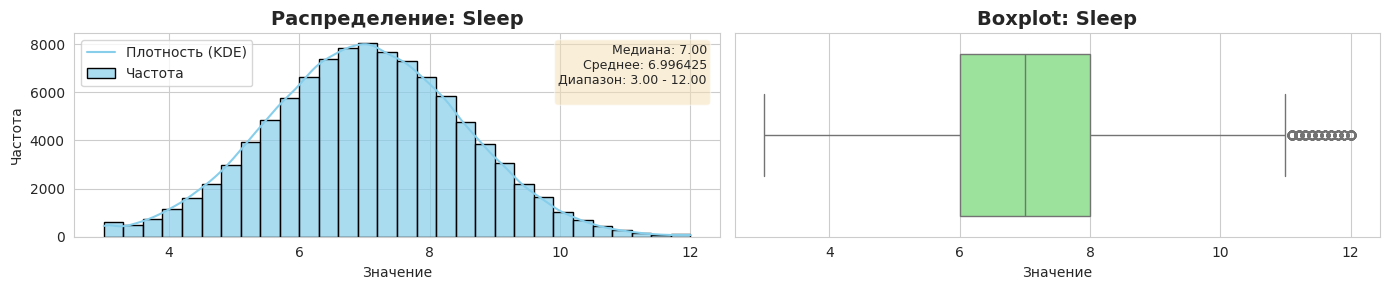

Выбросов (IQR) в Sleep: 369


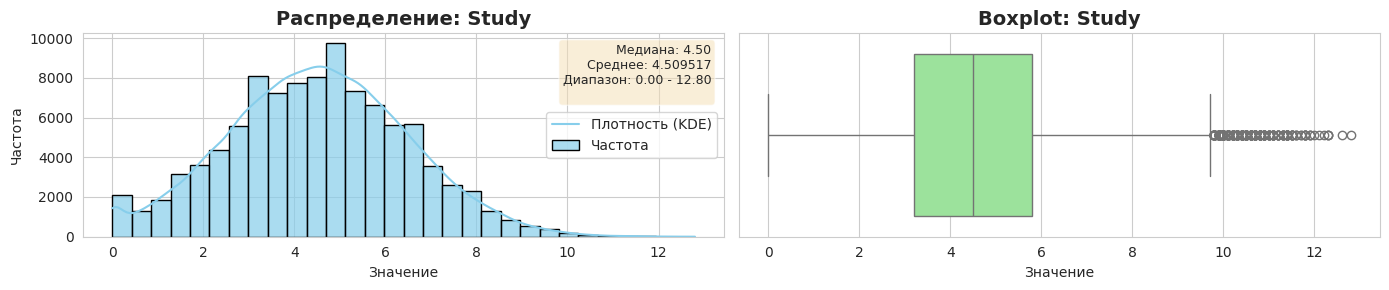

Выбросов (IQR) в Study: 432


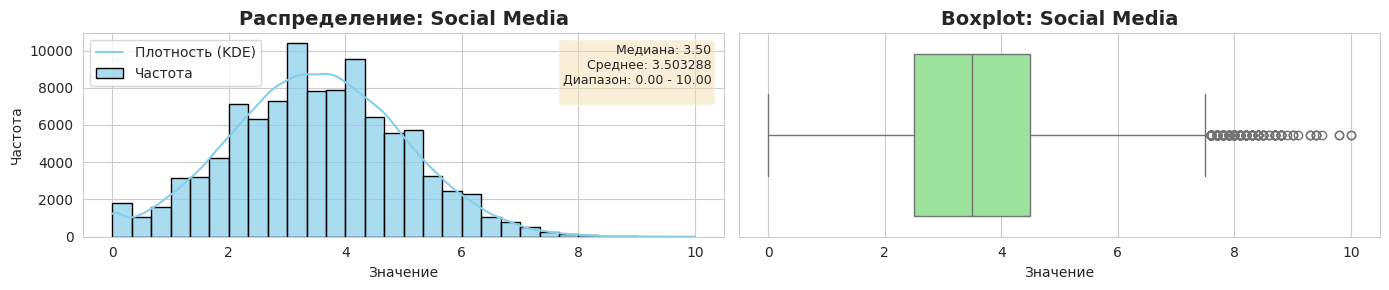

Выбросов (IQR) в Social Media: 328


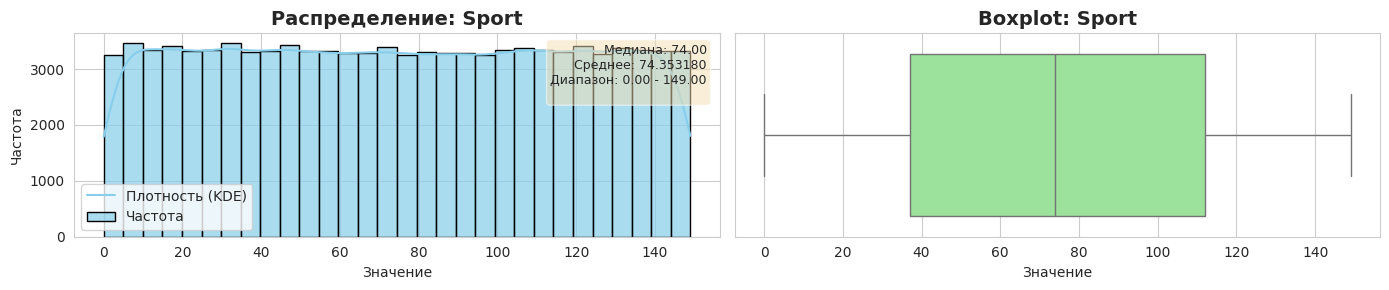

Выбросов (IQR) в Sport: 0


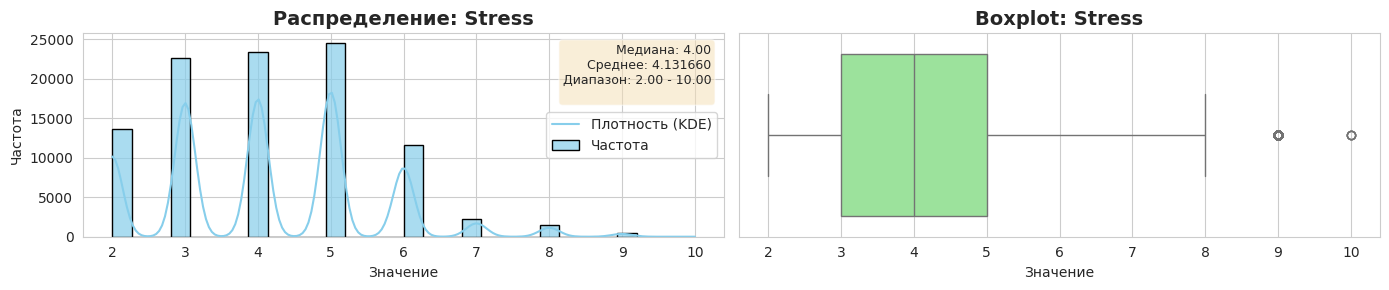

Выбросов (IQR) в Stress: 478


In [32]:
# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (16, 5)

# Выбираем только числовые колонки
numeric_cols = df.select_dtypes(include="number").columns.to_list()

print(f"Найдено числовых признаков: {len(numeric_cols)}\n")

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    # Гистограмма + KDE
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[0],
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    axes[0].set_title(f"Распределение: {col}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Значение")
    axes[0].set_ylabel("Частота")
    axes[0].legend(["Плотность (KDE)", "Частота"], loc="best")

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1], color="lightgreen")
    axes[1].set_title(f"Boxplot: {col}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Значение")

    # Статистика
    stats_text = (
        f"Медиана: {df[col].median():.2f}\n"
        f"Среднее: {df[col].mean():2f}\n"
        f"Диапазон: {df[col].min():.2f} - {df[col].max():.2f}\n"
    )

    axes[0].text(
        0.98,
        0.95,
        stats_text,
        transform=axes[0].transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()

    # Расчёт выбросов
    col_data = df[col]

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()

    # # Вывод в консоль
    print(f"Выбросов (IQR) в {col}: {outliers_count}")

In [ ]:
# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 5)

# Определяем категориальные признаки
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Добавить числовые колонки с малым числом уникальных значений
numeric_with_few_unique = [
    col for col in df.select_dtypes(include='number').columns
    if df[col].nunique() < 10 and df[col].nunique() > 1
]
cat_cols.extend(numeric_with_few_unique)

print(f"Найдено категориальных признаков: {len(cat_cols)}")
print(f"Признаки: {cat_cols}\n")

Найдено категориальных признаков: 4
Признаки: ['Gender', 'Department', 'Age', 'Stress']

